***Online Retail Sales Analysis & Customer Insights(EDA)***

**Step 1 — Data Loading**

In [29]:
import pandas as pd
df=pd.read_csv('/content/online_retail.csv')


**Step 2 — Data Understanding**

In [30]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [31]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
199623,554098,22026,BANQUET BIRTHDAY CARD,12.0,2011-05-22 13:01:00,0.42,14769.0,United Kingdom
199624,554098,22718,CARD CAT AND TREE,12.0,2011-05-22 13:01:00,0.42,14769.0,United Kingdom
199625,554098,22032,BOTANICAL LILY GREETING CARD,12.0,2011-05-22 13:01:00,0.42,14769.0,United Kingdom
199626,554098,22029,SPACEBOY BIRTHDAY CARD,12.0,2011-05-22 13:01:00,0.42,14769.0,United Kingdom
199627,554098,22028,PENNY FARTHING BIRTHD,NaN,NaN,NaN,NaN,NaN


In [32]:
df.shape

(199628, 8)

In [33]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199628 entries, 0 to 199627
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    199628 non-null  object 
 1   StockCode    199628 non-null  object 
 2   Description  198838 non-null  object 
 3   Quantity     199627 non-null  float64
 4   InvoiceDate  199627 non-null  object 
 5   UnitPrice    199627 non-null  float64
 6   CustomerID   141613 non-null  float64
 7   Country      199627 non-null  object 
dtypes: float64(3), object(5)
memory usage: 12.2+ MB


In [35]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,199627.000000,199627.000000,141613.000000
mean,9.284871,5.057015,15278.349050
std,240.716764,96.526995,1725.333857
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13835.000000
50%,3.000000,2.100000,15147.000000
75%,10.000000,4.210000,16813.000000
max,74215.000000,16888.020000,18287.000000


**Step 3 — Data Quality Check**

In [36]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,790
Quantity,1
InvoiceDate,1
UnitPrice,1
CustomerID,58015
Country,1


In [37]:
df.duplicated().sum()

np.int64(1684)

In [38]:
(df['Quantity'] < 0).sum()

np.int64(4197)

In [39]:
(df['Quantity'] < 0).head()

,Quantity
0,False
1,False
2,False
3,False
4,False


In [40]:
(df['UnitPrice'] < 0).sum()

np.int64(0)

In [41]:
df[df['Quantity'] < 0][['InvoiceNo', 'Quantity', 'Description', 'InvoiceDate', 'UnitPrice']].head(10)

,InvoiceNo,Quantity,Description,InvoiceDate,UnitPrice
141,C536379,-1.0,Discount,2010-12-01 09:41:00,27.50
154,C536383,-1.0,SET OF 3 COLOURED FLYING DUCKS,2010-12-01 09:49:00,4.65
235,C536391,-12.0,PLASTERS IN TIN CIRCUS PARADE,2010-12-01 10:24:00,1.65
236,C536391,-24.0,PACK OF 12 PINK PAISLEY TISSUES,2010-12-01 10:24:00,0.29
237,C536391,-24.0,PACK OF 12 BLUE PAISLEY TISSUES,2010-12-01 10:24:00,0.29
238,C536391,-24.0,PACK OF 12 RED RETROSPOT TISSUES,2010-12-01 10:24:00,0.29
239,C536391,-12.0,CHICK GREY HOT WATER BOTTLE,2010-12-01 10:24:00,3.45
240,C536391,-12.0,PLASTERS IN TIN VINTAGE PAISLEY,2010-12-01 10:24:00,1.65
241,C536391,-24.0,PLASTERS IN TIN SKULLS,2010-12-01 10:24:00,1.65
939,C536506,-6.0,JAM MAKING SET WITH JARS,2010-12-01 12:38:00,4.25


In [42]:
df[df['Quantity'] < 0]['InvoiceNo'].head(20)

,InvoiceNo
141,C536379
154,C536383
235,C536391
236,C536391
237,C536391
238,C536391
239,C536391
240,C536391
241,C536391
939,C536506


In [43]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


**Step 4 — Data Cleaning**

In [44]:
df_clean=df.copy()

In [45]:
df_clean = df_clean.drop_duplicates()

In [46]:
df_clean.duplicated().sum()

np.int64(0)

In [47]:
df_clean= df_clean[df_clean["Quantity"] > 0]

In [48]:
(df_clean['Quantity'] < 0).sum()

np.int64(0)

In [49]:
df_clean=df_clean[df_clean['UnitPrice'] > 0]

In [50]:
(df_clean['UnitPrice'] < 0).sum()

np.int64(0)

In [51]:
df_clean['InvoiceDate']=pd.to_datetime(df_clean['InvoiceDate'])

In [52]:
df_clean.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,float64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


**Step 5 — Revenue Creation**

In [53]:
df_clean['Revenue']= df_clean['Quantity'] * df_clean['UnitPrice']

**Step 6 — Quantity Analysis**

In [54]:
df_clean[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6.0,2.55,15.30
1,6.0,3.39,20.34
2,8.0,2.75,22.00
3,6.0,3.39,20.34
4,6.0,3.39,20.34


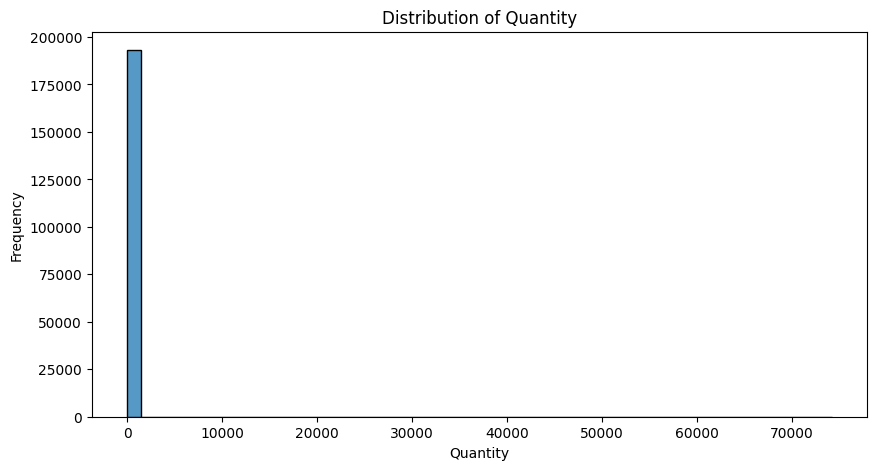

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df_clean['Quantity'], bins=50)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

In [56]:
df_clean['Quantity'].describe()

,Quantity
count,193145.000000
mean,10.393652
std,173.348694
min,1.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,74215.000000


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

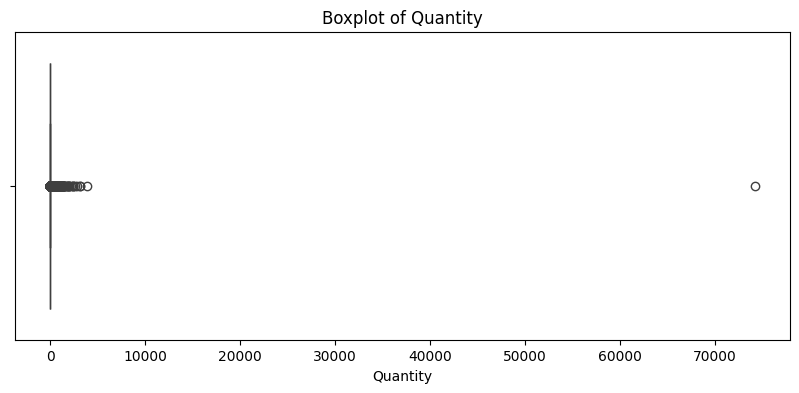

In [58]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df_clean['Quantity'])
plt.title('Boxplot of Quantity')
plt.show()

In [59]:
df_clean[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Country']].sort_values(
    by='Quantity',
    ascending=False
).head(10)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215.0,1.04,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906.0,0.82,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114.0,2.10,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114.0,2.10,United Kingdom
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880.0,0.18,United Kingdom
80742,543057,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2592.0,0.21,United Kingdom
87631,543669,22693,GROW A FLYTRAP OR SUNFLOWER IN TIN,2400.0,0.94,United Kingdom
91772,544152,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,2400.0,0.06,United Kingdom
32671,539101,22693,GROW A FLYTRAP OR SUNFLOWER IN TIN,2400.0,0.94,United Kingdom
125282,547037,21967,PACK OF 12 SKULL TISSUES,2160.0,0.25,United Kingdom


In [60]:
df_clean['Quantity'].nlargest(20)

,Quantity
61619,74215.0
97432,3906.0
52711,3114.0
160546,3114.0
4945,2880.0
80742,2592.0
32671,2400.0
87631,2400.0
91772,2400.0
125282,2160.0


In [61]:
Q1 = df_clean['Quantity'].quantile(0.25)
Q3 = df_clean['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 1.0
Q3: 10.0
IQR: 9.0
Lower Bound: -12.5
Upper Bound: 23.5


In [62]:
df_clean[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Country']].sort_values(
    by='Quantity',
    ascending=False
).head(10)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215.0,1.04,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906.0,0.82,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114.0,2.10,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114.0,2.10,United Kingdom
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880.0,0.18,United Kingdom
80742,543057,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2592.0,0.21,United Kingdom
87631,543669,22693,GROW A FLYTRAP OR SUNFLOWER IN TIN,2400.0,0.94,United Kingdom
91772,544152,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,2400.0,0.06,United Kingdom
32671,539101,22693,GROW A FLYTRAP OR SUNFLOWER IN TIN,2400.0,0.94,United Kingdom
125282,547037,21967,PACK OF 12 SKULL TISSUES,2160.0,0.25,United Kingdom


In [63]:
df_clean['Quantity'].nlargest(20)

,Quantity
61619,74215.0
97432,3906.0
52711,3114.0
160546,3114.0
4945,2880.0
80742,2592.0
32671,2400.0
87631,2400.0
91772,2400.0
125282,2160.0


In [64]:
Q1 = df_clean['Quantity'].quantile(0.25)
Q3 = df_clean['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 1.0
Q3: 10.0
IQR: 9.0
Lower Bound: -12.5
Upper Bound: 23.5


In [65]:
quantity_normal = df_clean[df_clean['Quantity'] <= 23.5]

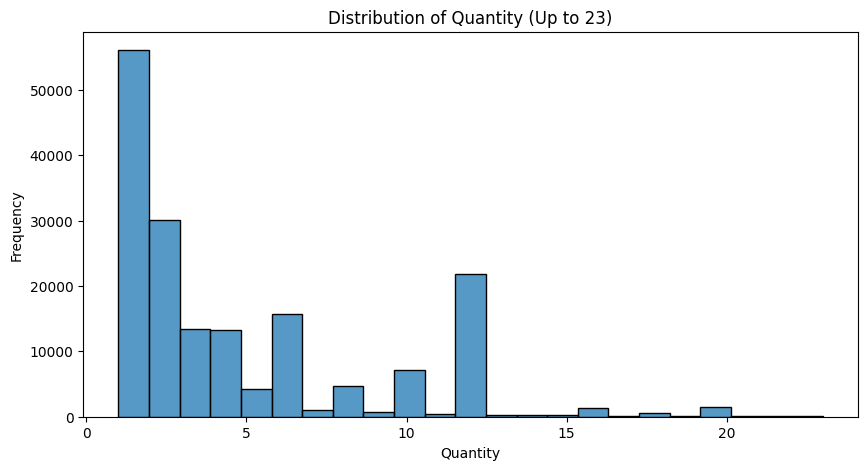

In [66]:
plt.figure(figsize=(10,5))

sns.histplot(quantity_normal['Quantity'], bins=23)

plt.title('Distribution of Quantity (Up to 23)')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.show()

In [67]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
199620,554098,22555,PLASTERS IN TIN STRONGMAN,2.0,2011-05-22 13:01:00,1.65,14769.0,United Kingdom,3.30
199621,554098,21790,VINTAGE SNAP CARDS,2.0,2011-05-22 13:01:00,0.85,14769.0,United Kingdom,1.70
199622,554098,22031,BOTANICAL LAVENDER BIRTHDAY CARD,12.0,2011-05-22 13:01:00,0.42,14769.0,United Kingdom,5.04
199625,554098,22032,BOTANICAL LILY GREETING CARD,12.0,2011-05-22 13:01:00,0.42,14769.0,United Kingdom,5.04


**Step 7 — UnitPrice Analysis**

In [68]:
df_clean['UnitPrice'].describe()

,UnitPrice
count,193145.000000
mean,4.177521
std,40.351131
min,0.001000
25%,1.250000
50%,2.170000
75%,4.210000
max,13541.330000


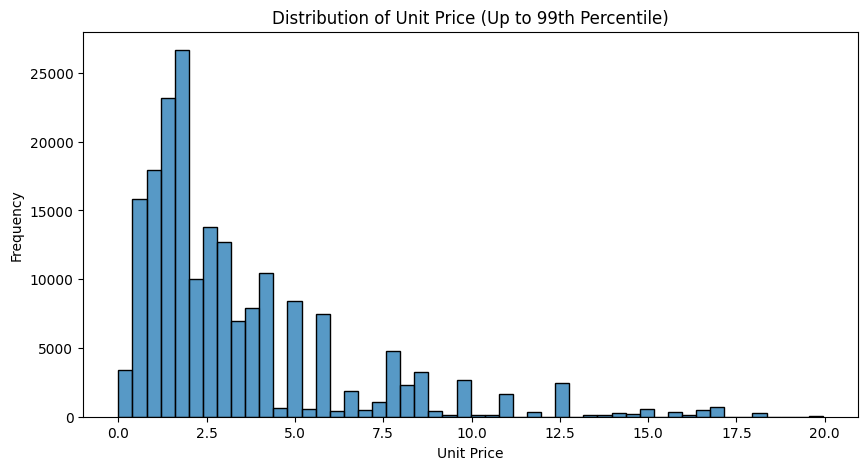

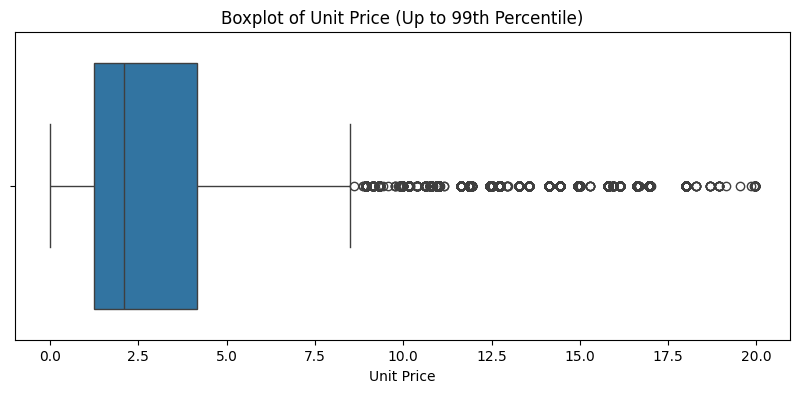

In [135]:
# Handle extreme outliers for better visualization
price_99 = df_clean['UnitPrice'].quantile(0.99)

unitprice_visual = df_clean[
    df_clean['UnitPrice'] <= price_99
]['UnitPrice']

# Histogram
plt.figure(figsize=(10,5))

sns.histplot(unitprice_visual, bins=50)

plt.title('Distribution of Unit Price (Up to 99th Percentile)')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')

plt.show()


# Boxplot
plt.figure(figsize=(10,4))

sns.boxplot(x=unitprice_visual)

plt.title('Boxplot of Unit Price (Up to 99th Percentile)')
plt.xlabel('Unit Price')

plt.show()

**Step 8 — Revenue Analysis**

In [71]:
df_clean['Revenue'].describe()

,Revenue
count,193145.000000
mean,19.984642
std,190.987813
min,0.001000
25%,4.130000
50%,10.000000
75%,17.700000
max,77183.600000


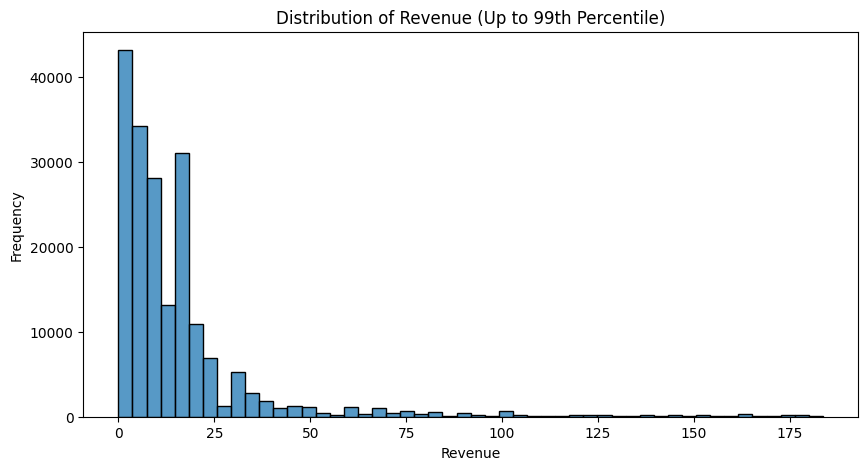

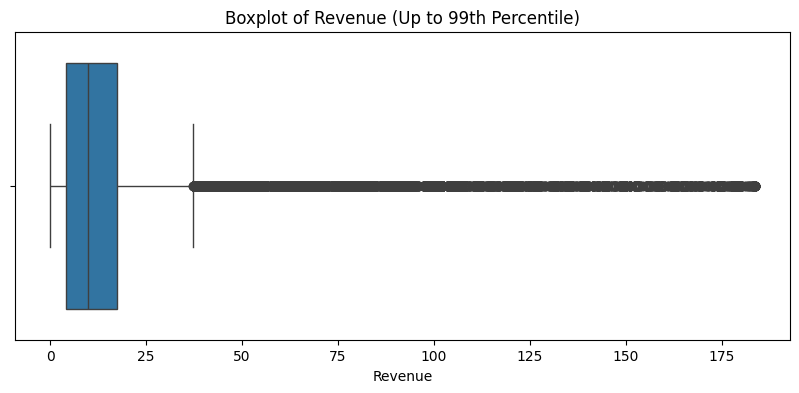

In [136]:
# Handle extreme outliers for better visualization
revenue_99 = df_clean['Revenue'].quantile(0.99)

revenue_visual = df_clean[
    df_clean['Revenue'] <= revenue_99
]['Revenue']

# Histogram
plt.figure(figsize=(10,5))

sns.histplot(revenue_visual, bins=50)

plt.title('Distribution of Revenue (Up to 99th Percentile)')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.show()


# Boxplot
plt.figure(figsize=(10,4))

sns.boxplot(x=revenue_visual)

plt.title('Boxplot of Revenue (Up to 99th Percentile)')
plt.xlabel('Revenue')

plt.show()

In [74]:
df_clean[['InvoiceNo', 'StockCode', 'Description',
          'Quantity', 'UnitPrice', 'Revenue', 'Country']] \
    .sort_values(by='Revenue', ascending=False) \
    .head(10)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215.0,1.04,77183.60,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1.0,13541.33,13541.33,United Kingdom
173382,551697,POST,POSTAGE,1.0,8142.75,8142.75,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114.0,2.10,6539.40,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114.0,2.10,6539.40,United Kingdom
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930.0,2.55,4921.50,United Kingdom
160542,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930.0,2.40,4632.00,United Kingdom
52772,540818,48185,DOORMAT FAIRY CAKE,670.0,6.75,4522.50,United Kingdom
160544,550461,48185,DOORMAT FAIRY CAKE,670.0,6.35,4254.50,United Kingdom
52134,540689,22470,HEART OF WICKER LARGE,1284.0,3.21,4121.64,United Kingdom


**Step 9 — Country Analysis**

In [75]:
df_clean['Country'].nunique()

36

In [76]:
country_orders = df_clean['Country'].value_counts()

country_orders.head(10)

,count
Country,
United Kingdom,178106
Germany,3081
France,2835
EIRE,2368
Spain,906
Netherlands,838
Belgium,632
Portugal,559
Switzerland,556


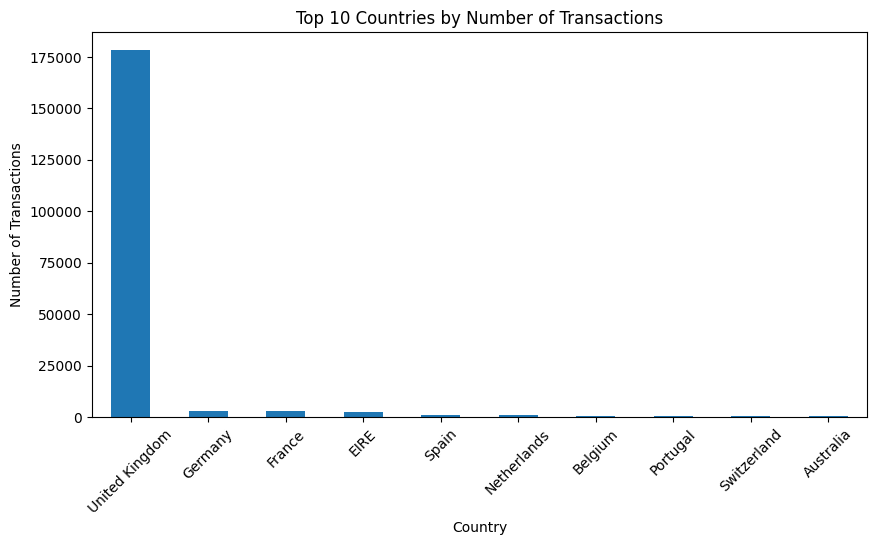

In [77]:
plt.figure(figsize=(10,5))

country_orders.head(10).plot(kind='bar')

plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)

plt.show()

In [78]:
country_revenue = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

country_revenue.head(10)

,Revenue
Country,
United Kingdom,3268908.701
Netherlands,102130.580
EIRE,90411.130
Germany,88689.900
France,69799.380
Australia,55840.390
Spain,23095.830
Japan,21434.730
Sweden,16041.780


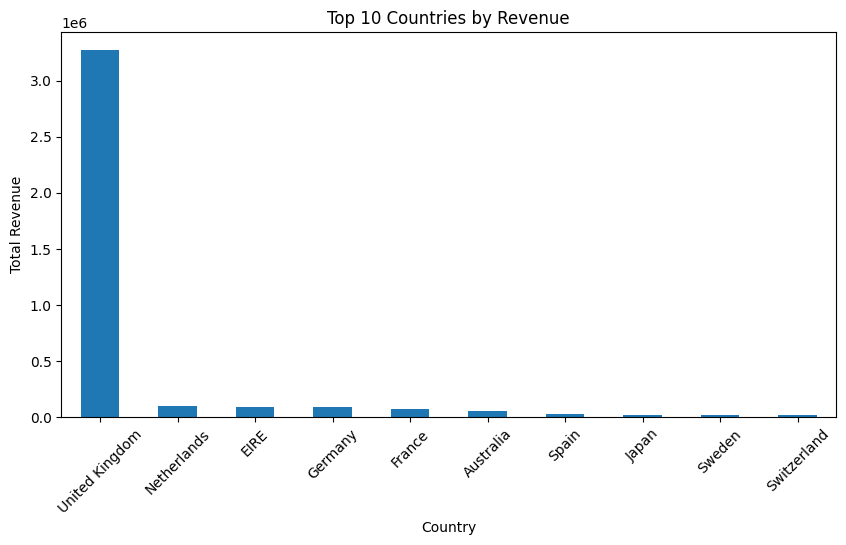

In [79]:
plt.figure(figsize=(10,5))

country_revenue.head(10).plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.show()

**Step 10 — Product Analysis**

In [80]:
top_products_orders = (
    df_clean['Description']
    .value_counts()
    .head(10)
)

top_products_orders

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,1112
REGENCY CAKESTAND 3 TIER,959
JUMBO BAG RED RETROSPOT,798
PARTY BUNTING,722
LUNCH BAG RED RETROSPOT,626
PACK OF 72 RETROSPOT CAKE CASES,623
ASSORTED COLOUR BIRD ORNAMENT,592
SET OF 3 CAKE TINS PANTRY DESIGN,590
NATURAL SLATE HEART CHALKBOARD,578


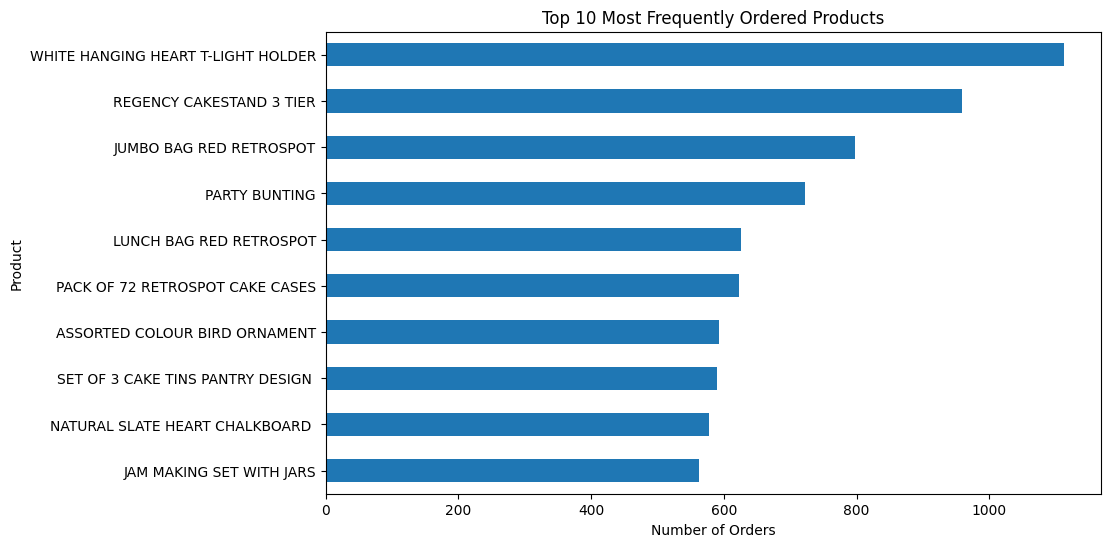

In [81]:
plt.figure(figsize=(10,6))

top_products_orders.sort_values().plot(kind='barh')

plt.title('Top 10 Most Frequently Ordered Products')
plt.xlabel('Number of Orders')
plt.ylabel('Product')

plt.show()

In [82]:
top_products_quantity = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

,Quantity
Description,
MEDIUM CERAMIC TOP STORAGE JAR,74788.0
WORLD WAR 2 GLIDERS ASSTD DESIGNS,27505.0
WHITE HANGING HEART T-LIGHT HOLDER,19922.0
PACK OF 72 RETROSPOT CAKE CASES,19555.0
JUMBO BAG RED RETROSPOT,18312.0
SMALL POPCORN HOLDER,14142.0
ASSORTED COLOUR BIRD ORNAMENT,13379.0
PACK OF 12 LONDON TISSUES,13121.0
ASSORTED COLOURS SILK FAN,12665.0


In [83]:
top_products_quantity = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

,Quantity
Description,
MEDIUM CERAMIC TOP STORAGE JAR,74788.0
WORLD WAR 2 GLIDERS ASSTD DESIGNS,27505.0
WHITE HANGING HEART T-LIGHT HOLDER,19922.0
PACK OF 72 RETROSPOT CAKE CASES,19555.0
JUMBO BAG RED RETROSPOT,18312.0
SMALL POPCORN HOLDER,14142.0
ASSORTED COLOUR BIRD ORNAMENT,13379.0
PACK OF 12 LONDON TISSUES,13121.0
ASSORTED COLOURS SILK FAN,12665.0


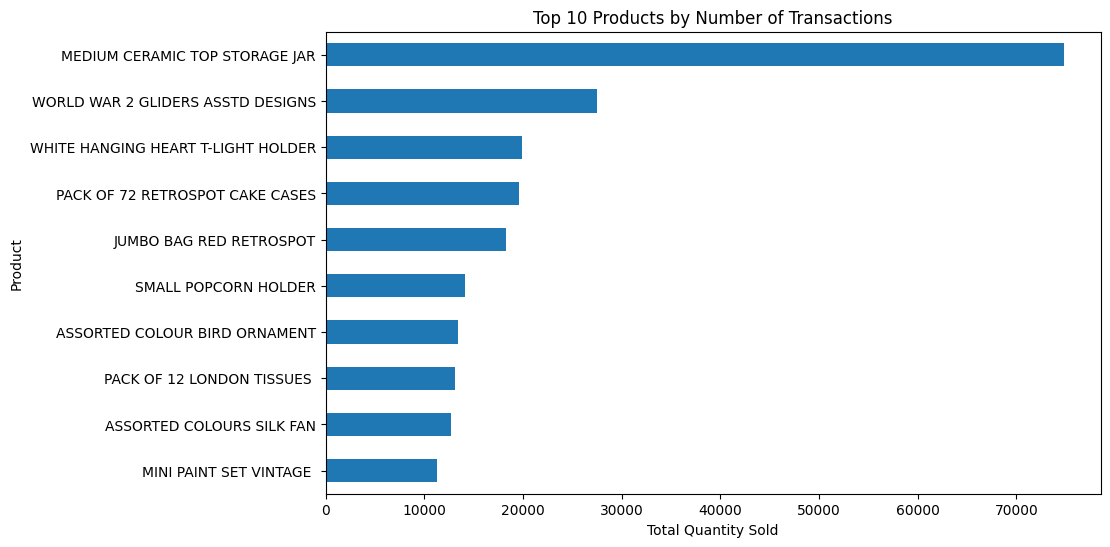

In [137]:
plt.figure(figsize=(10,6))

top_products_quantity.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Number of Transactions')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')

plt.show()

In [85]:
top_products_revenue = (
    df_clean.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,94589.69
MEDIUM CERAMIC TOP STORAGE JAR,77813.97
DOTCOM POSTAGE,75799.68
WHITE HANGING HEART T-LIGHT HOLDER,54959.58
PARTY BUNTING,40719.16
JUMBO BAG RED RETROSPOT,34811.64
POSTAGE,33071.70
Manual,24335.14
CHILLI LIGHTS,22265.82


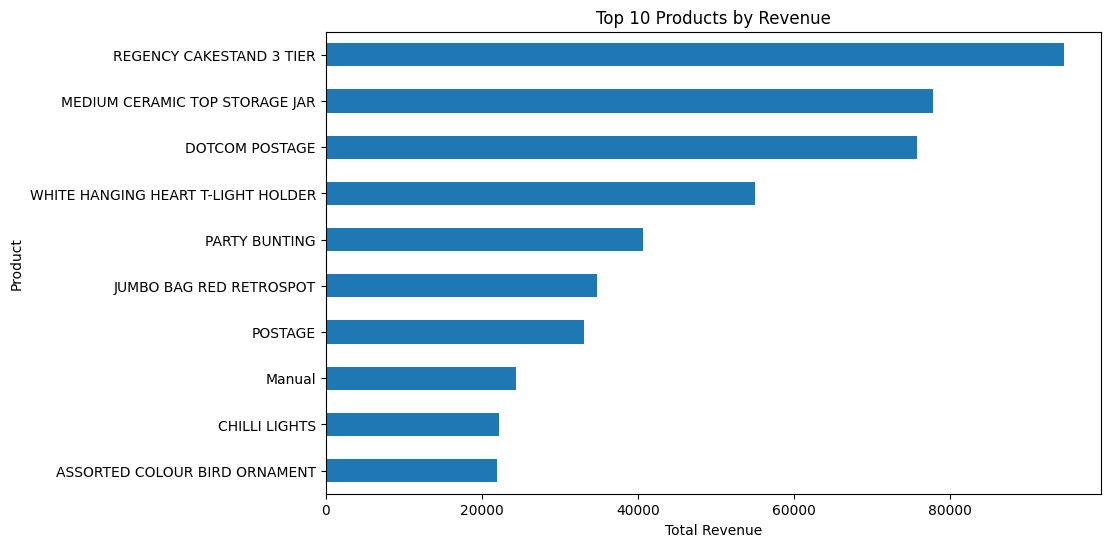

In [86]:
plt.figure(figsize=(10,6))

top_products_revenue.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')

plt.show()

**Step 11 — Time Series Analysis**

In [87]:
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

In [88]:
df_clean[['InvoiceDate', 'YearMonth']].head()

,InvoiceDate,YearMonth
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [89]:
monthly_revenue = (
    df_clean.groupby('YearMonth')['Revenue']
    .sum()
)

monthly_revenue

,Revenue
YearMonth,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,572940.030


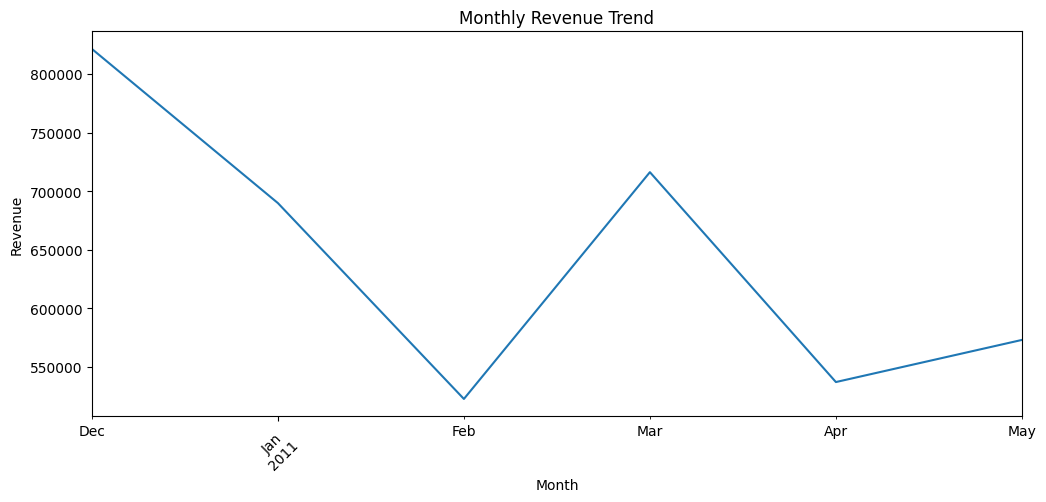

In [90]:
plt.figure(figsize=(12,5))

monthly_revenue.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

In [91]:
monthly_revenue.sort_values(ascending=False).head(5)

,Revenue
YearMonth,
2010-12,821452.730
2011-03,716215.260
2011-01,689811.610
2011-05,572940.030
2011-04,536968.491


In [92]:
monthly_orders = (
    df_clean.groupby('YearMonth')['InvoiceNo']
    .nunique()
)

monthly_orders

,InvoiceNo
YearMonth,
2010-12,1559
2011-01,1086
2011-02,1100
2011-03,1454
2011-04,1246
2011-05,1250


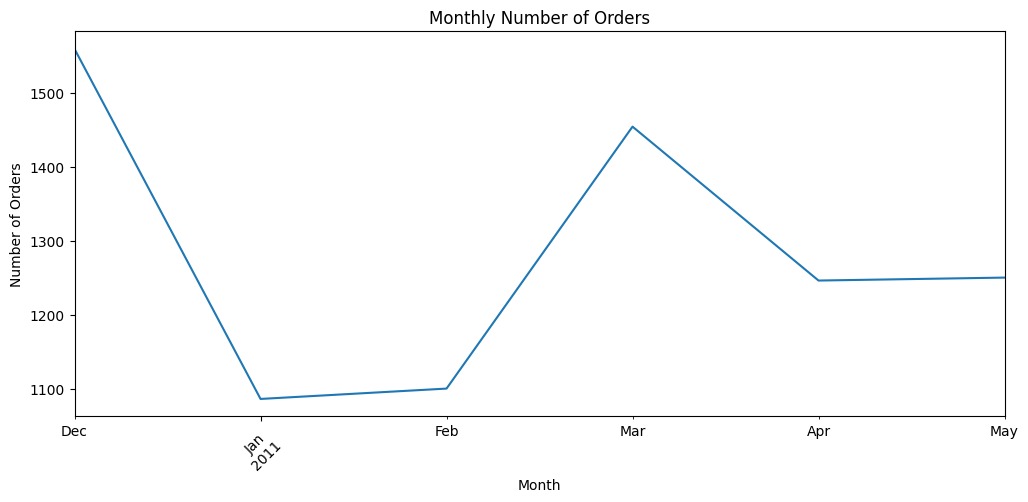

In [93]:
plt.figure(figsize=(12,5))

monthly_orders.plot()

plt.title('Monthly Number of Orders')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.show()

In [94]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [95]:
df_clean['InvoiceDate'].dtype

dtype('<M8[ns]')

In [96]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')

In [97]:
df_clean[['InvoiceDate', 'Month']].head()

,InvoiceDate,Month
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [98]:
monthly_revenue = df_clean.groupby('Month')['Revenue'].sum()

In [99]:
monthly_revenue

,Revenue
Month,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,572940.030


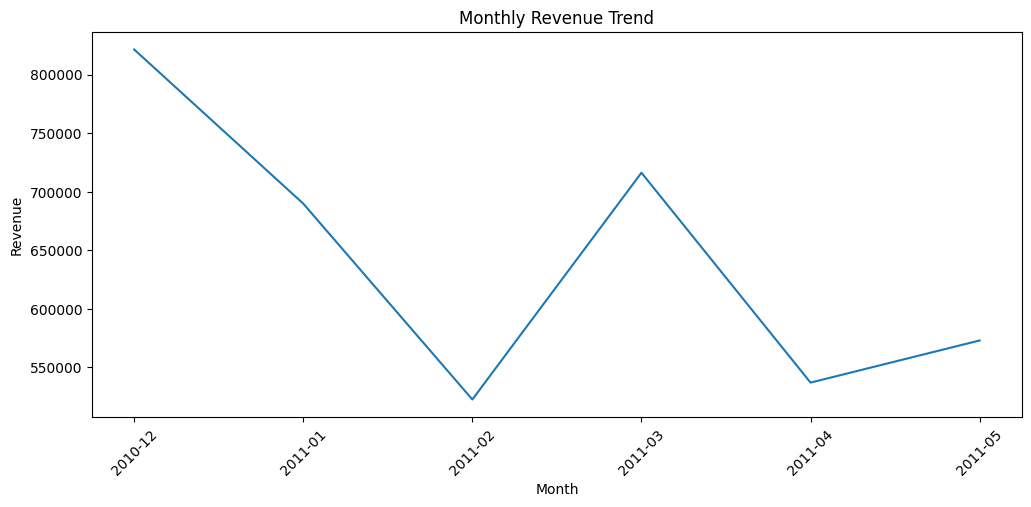

In [100]:
plt.figure(figsize=(12,5))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [101]:
monthly_quantity = df_clean.groupby('Month')['Quantity'].sum()

In [102]:
monthly_quantity

,Quantity
Month,
2010-12,358019.0
2011-01,387099.0
2011-02,282934.0
2011-03,376599.0
2011-04,307953.0
2011-05,294878.0


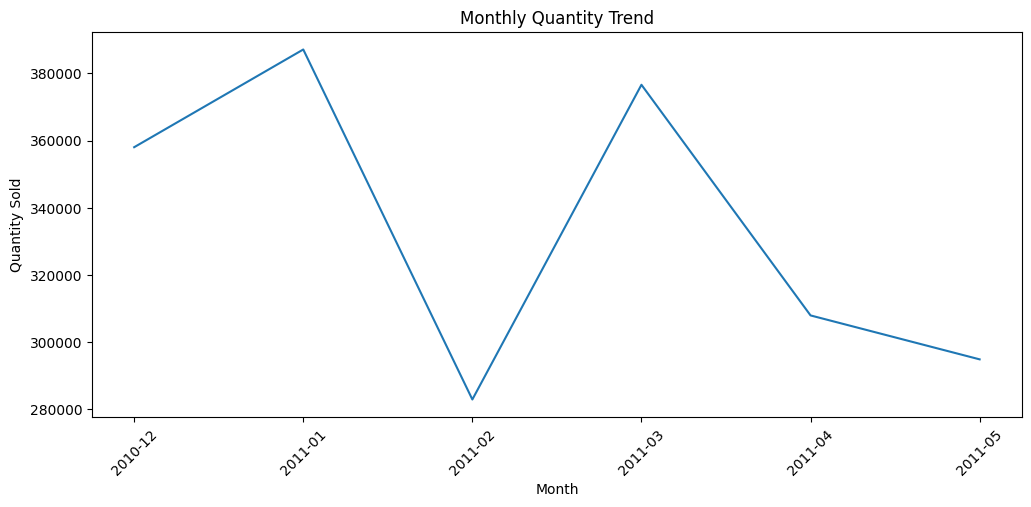

In [103]:
plt.figure(figsize=(12,5))
plt.plot(monthly_quantity.index.astype(str), monthly_quantity.values)
plt.title('Monthly Quantity Trend')
plt.xlabel('Month')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

In [104]:
best_month = monthly_revenue.idxmax()
best_revenue = monthly_revenue.max()

worst_month = monthly_revenue.idxmin()
worst_revenue = monthly_revenue.min()

print("Best Month:", best_month)
print("Best Revenue:", best_revenue)

print("Worst Month:", worst_month)
print("Worst Revenue:", worst_revenue)

Best Month: 2010-12
Best Revenue: 821452.73
Worst Month: 2011-02
Worst Revenue: 522545.56


In [105]:
daily_revenue = df_clean.groupby(df_clean['InvoiceDate'].dt.date)['Revenue'].sum()

In [106]:
daily_revenue.head()

,Revenue
InvoiceDate,
2010-12-01,58776.79
2010-12-02,47629.42
2010-12-03,46898.63
2010-12-05,31364.63
2010-12-06,54624.15


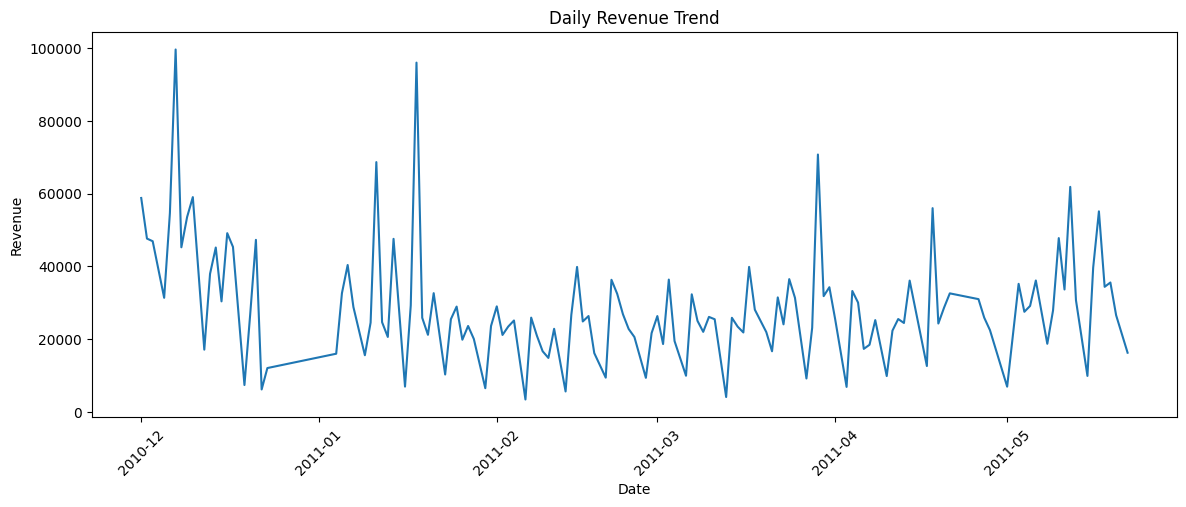

In [107]:
plt.figure(figsize=(14,5))
plt.plot(daily_revenue.index, daily_revenue.values)
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

**Step 12 — Customer Analysis**

In [108]:
df_clean['CustomerID'].nunique()

2655

In [109]:
customer_revenue = df_clean.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

customer_revenue.head(10)

,Revenue
CustomerID,
14646.0,100340.24
12346.0,77183.60
18102.0,64642.11
12415.0,50883.90
15749.0,44534.30
14156.0,43892.23
17450.0,37734.58
14911.0,37292.95
17511.0,35750.40


In [110]:
customer_quantity = df_clean.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False)

customer_quantity.head(10)


,Quantity
CustomerID,
12346.0,74215.0
14646.0,73134.0
14298.0,32416.0
12415.0,31999.0
13694.0,25500.0
17511.0,24836.0
14156.0,20200.0
16333.0,20108.0
16684.0,18629.0


In [111]:
customer_orders = df_clean.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False)

customer_orders.head(10)

,InvoiceNo
CustomerID,
12748.0,83
14911.0,57
13089.0,49
14606.0,46
17841.0,43
15311.0,40
12971.0,37
17850.0,34
13798.0,29


In [112]:
customer_aov = (
    df_clean.groupby('CustomerID')['Revenue'].sum()
    / df_clean.groupby('CustomerID')['InvoiceNo'].nunique()
)

**Step 13 — Correlation Analysis**

In [113]:
customer_aov.sort_values(ascending=False).head(10)

,0
CustomerID,
12346.0,77183.600000
15749.0,14844.766667
14088.0,7544.910000
12415.0,7269.128571
12590.0,4932.130000
14646.0,4362.619130
18102.0,4309.474000
12435.0,3978.990000
17450.0,3773.458000


In [114]:
corr = df_clean[['Quantity', 'UnitPrice', 'Revenue']].corr()
corr

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003350,0.944999
UnitPrice,-0.003350,1.000000,0.210955
Revenue,0.944999,0.210955,1.000000


**Step 14 — Additional Business Analysis**

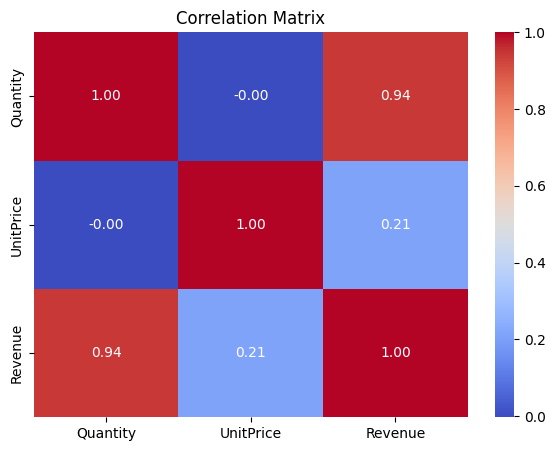

In [115]:
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [116]:
top_products = (
    df_clean.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,94589.69
MEDIUM CERAMIC TOP STORAGE JAR,77813.97
DOTCOM POSTAGE,75799.68
WHITE HANGING HEART T-LIGHT HOLDER,54959.58
PARTY BUNTING,40719.16
JUMBO BAG RED RETROSPOT,34811.64
POSTAGE,33071.70
Manual,24335.14
CHILLI LIGHTS,22265.82


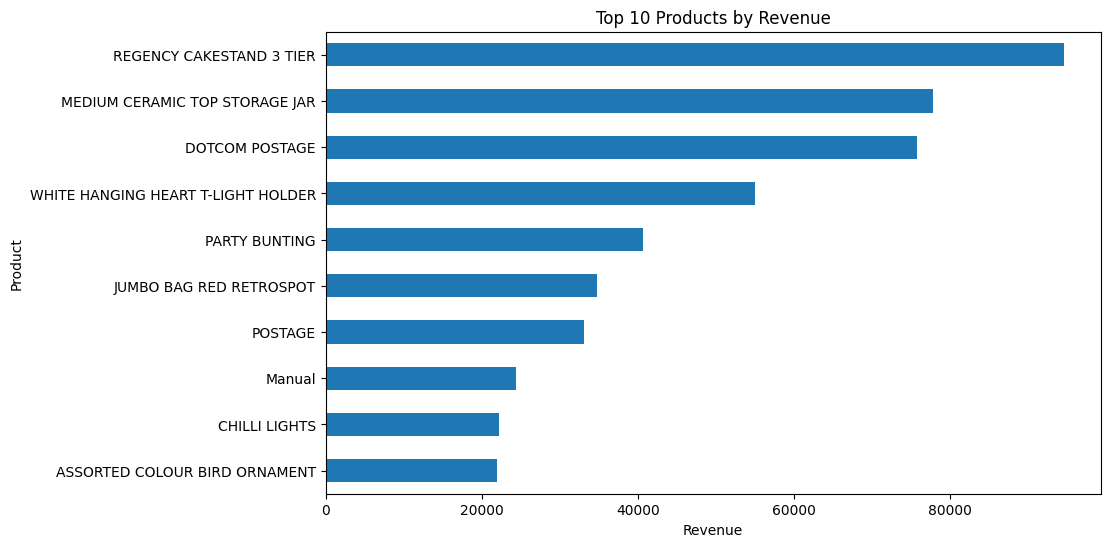

In [117]:
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

In [118]:
monthly_growth = monthly_revenue.pct_change() * 100

In [119]:
monthly_growth

,Revenue
Month,
2010-12,NaN
2011-01,-16.025404
2011-02,-24.248077
2011-03,37.062740
2011-04,-25.026941
2011-05,6.699004


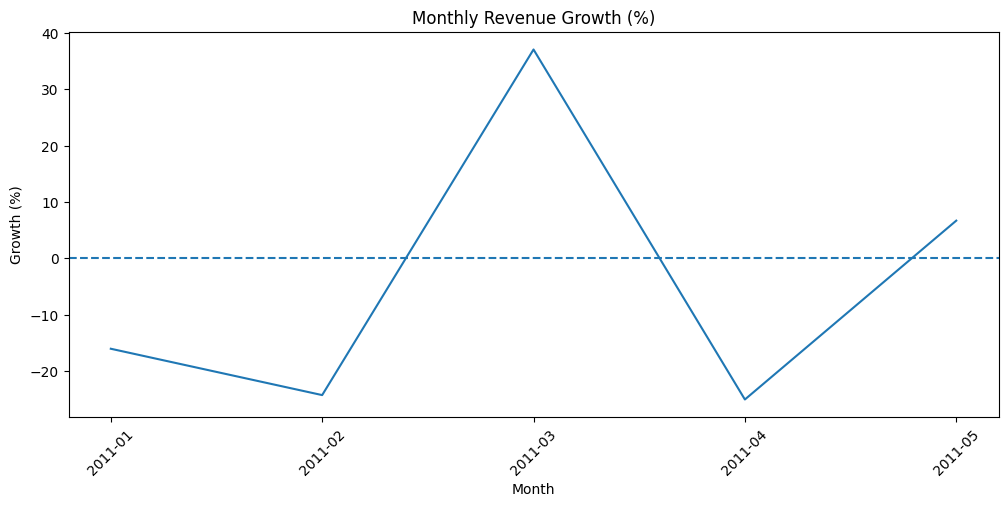

In [120]:
plt.figure(figsize=(12,5))
plt.plot(monthly_growth.index.astype(str), monthly_growth.values)
plt.title('Monthly Revenue Growth (%)')
plt.xlabel('Month')
plt.ylabel('Growth (%)')
plt.xticks(rotation=45)
plt.axhline(0, linestyle='--')
plt.show()

In [121]:
country_avg_revenue = (
    df_clean.groupby('Country')['Revenue']
    .mean()
    .sort_values(ascending=False)
)

country_avg_revenue.head(10)

,Revenue
Country,
Netherlands,121.874200
Australia,118.305911
Sweden,100.261125
Japan,95.690759
Singapore,90.819912
Denmark,79.171923
Canada,61.343636
Lithuania,47.458857
Hong Kong,46.483352


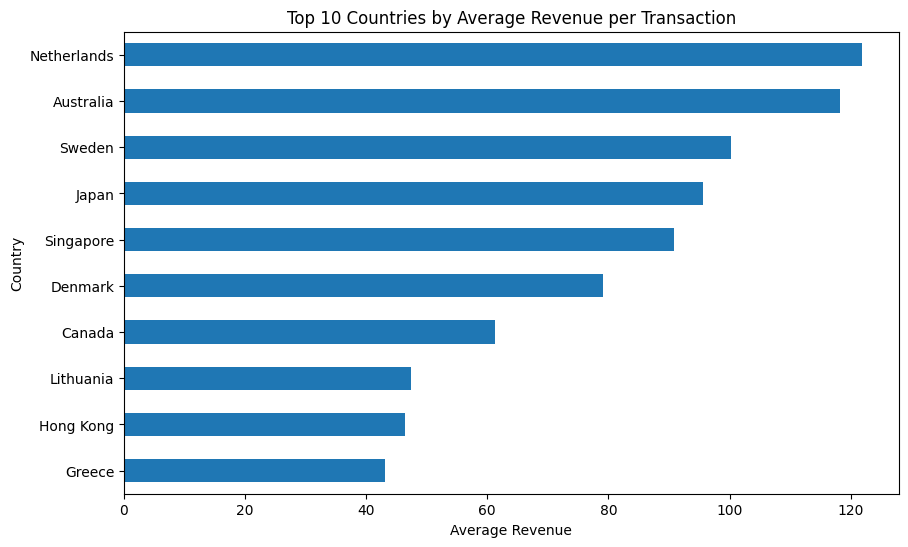

In [122]:
plt.figure(figsize=(10,6))
country_avg_revenue.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Average Revenue per Transaction')
plt.xlabel('Average Revenue')
plt.ylabel('Country')
plt.show()

In [123]:
orders_per_customer = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()

repeat_customers = (orders_per_customer > 1).sum()
one_time_customers = (orders_per_customer == 1).sum()

print("Repeat Customers:", repeat_customers)
print("One-time Customers:", one_time_customers)

Repeat Customers: 1319
One-time Customers: 1336


In [124]:
repeat_customer_percentage = (
    repeat_customers / len(orders_per_customer)
) * 100

print("Repeat Customer %:", repeat_customer_percentage)

Repeat Customer %: 49.67984934086629


In [125]:
high_value_customers = (
    df_clean.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

high_value_customers

,Revenue
CustomerID,
14646.0,100340.24
12346.0,77183.60
18102.0,64642.11
12415.0,50883.90
15749.0,44534.30
14156.0,43892.23
17450.0,37734.58
14911.0,37292.95
17511.0,35750.40


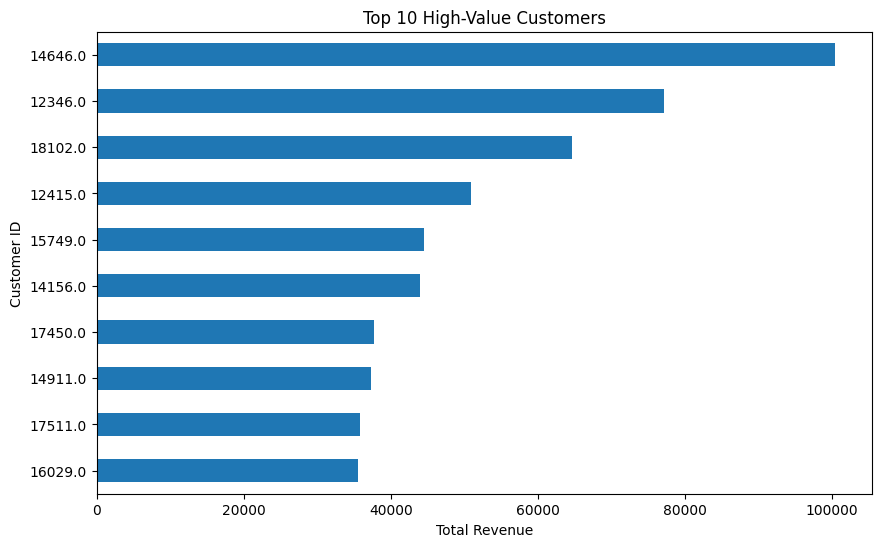

In [126]:
plt.figure(figsize=(10,6))
high_value_customers.sort_values().plot(kind='barh')
plt.title('Top 10 High-Value Customers')
plt.xlabel('Total Revenue')
plt.ylabel('Customer ID')
plt.show()

**Final verdict**

In [127]:
print("Total Revenue:", df_clean['Revenue'].sum())
print("Total Quantity Sold:", df_clean['Quantity'].sum())
print("Total Orders:", df_clean['InvoiceNo'].nunique())
print("Total Customers:", df_clean['CustomerID'].nunique())
print("Total Products:", df_clean['Description'].nunique())
print("Total Countries:", df_clean['Country'].nunique())

Total Revenue: 3859933.6809999994
Total Quantity Sold: 2007482.0
Total Orders: 7695
Total Customers: 2655
Total Products: 3357
Total Countries: 36


In [128]:
print("Best Revenue Month:", best_month)
print("Best Month Revenue:", best_revenue)
print("Worst Revenue Month:", worst_month)
print("Worst Month Revenue:", worst_revenue)

Best Revenue Month: 2010-12
Best Month Revenue: 821452.73
Worst Revenue Month: 2011-02
Worst Month Revenue: 522545.56


In [129]:
average_order_value = df_clean['Revenue'].sum() / df_clean['InvoiceNo'].nunique()
print(f"Average Order Value: {average_order_value:,.2f}")

Average Order Value: 501.62


In [130]:
avg_customer_revenue = df_clean.groupby('CustomerID')['Revenue'].sum().mean()
print(f"Average Revenue per Customer: {avg_customer_revenue:,.2f}")

Average Revenue per Customer: 1,187.08


In [131]:
print(f"Repeat Customer Percentage: {repeat_customer_percentage:.2f}%")

Repeat Customer Percentage: 49.68%


In [132]:
correlation = df_clean[['Quantity', 'UnitPrice', 'Revenue']].corr()

print(correlation)

           Quantity  UnitPrice   Revenue
Quantity   1.000000  -0.003350  0.944999
UnitPrice -0.003350   1.000000  0.210955
Revenue    0.944999   0.210955  1.000000


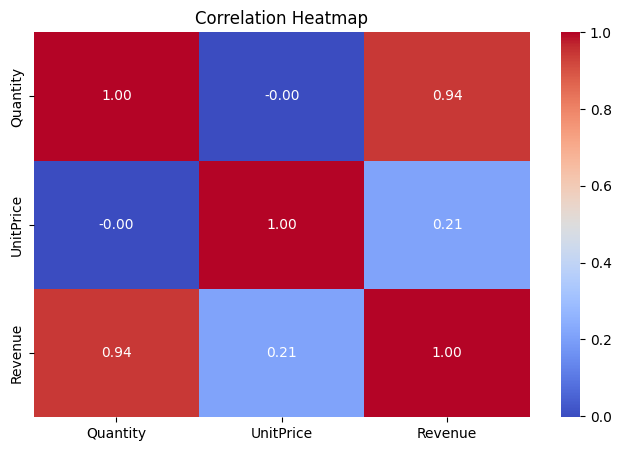

In [133]:
plt.figure(figsize=(8,5))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()